In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-21 16:14:33--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz’

mito.npz            100%[===================>]  35.87M  84.2MB/s    in 0.4s    

2026-04-21 16:14:35 (84.2 MB/s) - ‘mito.npz’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [7]:
# TODO: What does the above code do?
# The code performs Min-Max Normalization on the image data by subtracting the minimum pixel value and dividing by the range, 
# which scales all pixel intensities to a standard [0, 1] interval for better model stability. 
# It also processes the masks by first converting them to booleans to ensure they are strictly binary and then casting them to floats

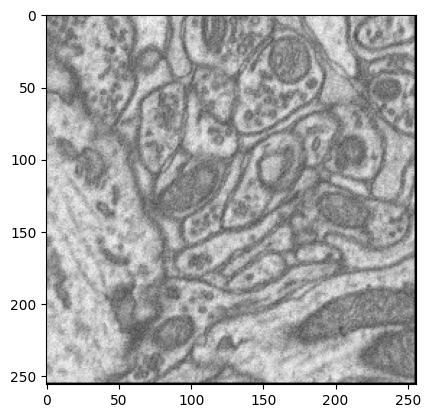

In [8]:
imshow(images[0], cmap='gray')

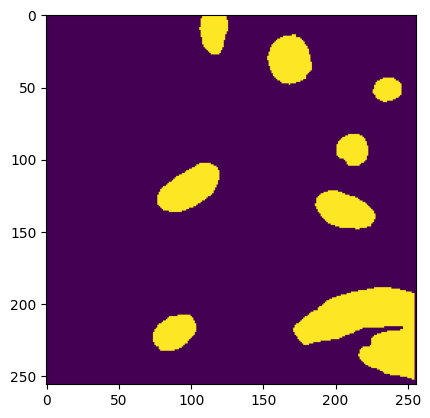

In [9]:
imshow(masks[0])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [11]:
# TODO: What does the above code do?
# This code partitions the dataset into three sets to evaluate model generalization:
# 70% for training, 15% for validation (tuning) and 15% for testing (final evaluation). By using two sequential splits and a fixed random_state, 
# it ensures the proportions are consistent and the results are reproducible every time the notebook is executed.

## 2. Make the Data Pytorch-ready! (10 points)

In [12]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [13]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [14]:
# TODO: What does the above code do?
# This code defines an augmentation pipeline using the Albumentations library to artificially increase the diversity of the training data.
# The train_transform applies random horizontal flips, vertical flips, and 90-degree rotations ensuring the model sees different orientations 
# of the same mitochondria images to improve its robustness. Conversely, val_transform is kept empty because validation and test data should 
# remain unaltered to provide an accurate and consistent measure of the model's performance on real-world inputs.

In [15]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [16]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [18]:
# TODO: What does the above code do?
# This code creates a custom PyTorch Dataset class and DataLoaders to efficiently manage the flow of data during training. 
# The MitoDataset class handles retrieving individual image-mask pairs, applying the transformations defined earlier, 
# adding a required channel dimension for PyTorch, and converting the NumPy arrays into tensors.
# The DataLoader then wraps these datasets to handle batching (processing 16 images at a time), 
# shuffling the training data to prevent the model from learning the order of samples, and using multiple worker processes to speed up data loading.

## 3. Configure the Classifier! (30 points)

In [19]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [20]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [21]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [22]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [23]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4475, train_dice=0.6212 | val_loss=0.3968, val_dice=0.6142
Epoch 2/10 | train_loss=0.1853, train_dice=0.8311 | val_loss=0.2216, val_dice=0.7619
Epoch 3/10 | train_loss=0.1148, train_dice=0.8682 | val_loss=0.1006, val_dice=0.8864
Epoch 4/10 | train_loss=0.0815, train_dice=0.9003 | val_loss=0.0639, val_dice=0.9234
Epoch 5/10 | train_loss=0.0774, train_dice=0.9012 | val_loss=0.0620, val_dice=0.9235
Epoch 6/10 | train_loss=0.0636, train_dice=0.9187 | val_loss=0.0731, val_dice=0.8995
Epoch 7/10 | train_loss=0.0597, train_dice=0.9223 | val_loss=0.0559, val_dice=0.9214
Epoch 8/10 | train_loss=0.0538, train_dice=0.9279 | val_loss=0.0484, val_dice=0.9365
Epoch 9/10 | train_loss=0.0490, train_dice=0.9345 | val_loss=0.0469, val_dice=0.9388
Epoch 10/10 | train_loss=0.0464, train_dice=0.9384 | val_loss=0.0434, val_dice=0.9437
Best val dice: 0.9437107699257987


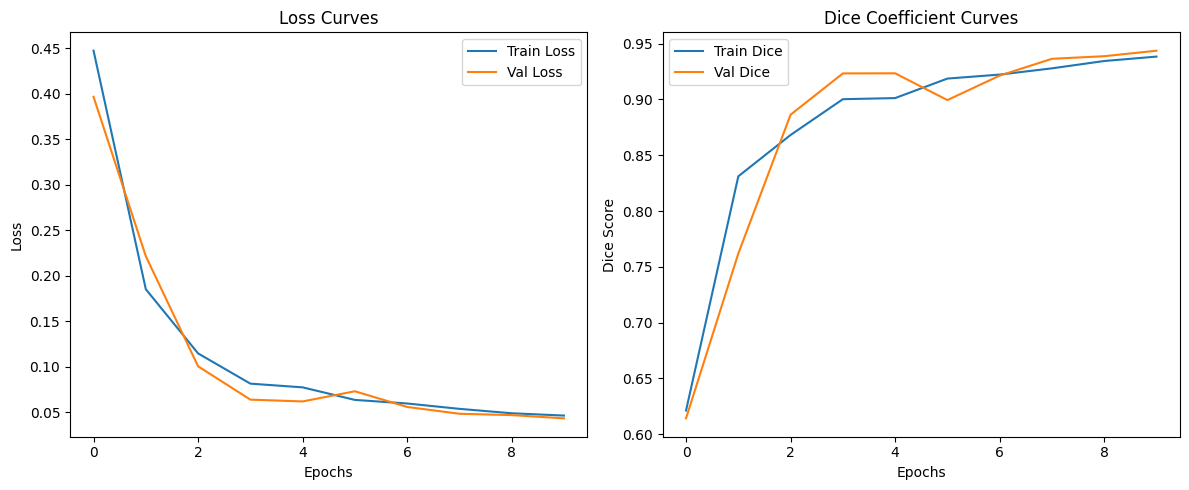

In [28]:
# TODO: Plot the loss and dice curves!
plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Dice Scores
plt.subplot(1, 2, 2)
plt.plot(train_dices, label='Train Dice')
plt.plot(val_dices, label='Val Dice')
plt.title('Dice Coefficient Curves')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# TODO: Do these plots look good?
# Yes, these plots look good. Both the training and validation loss decrease rapidly and stabilize at a low value. 
# Moreover, the validation loss closely tracks the training loss without spiking back up, which means the model is learning without overfitting.
# On the ohter hand, the Dice scores climb steadily and plateau at a very high value. The fact that the validation score stays close to
# the training score proves the model generalizes well to unseen data.

## 5. Testing the U-Net. (20 points)

In [29]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0446
Test dice: 0.9439


In [30]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

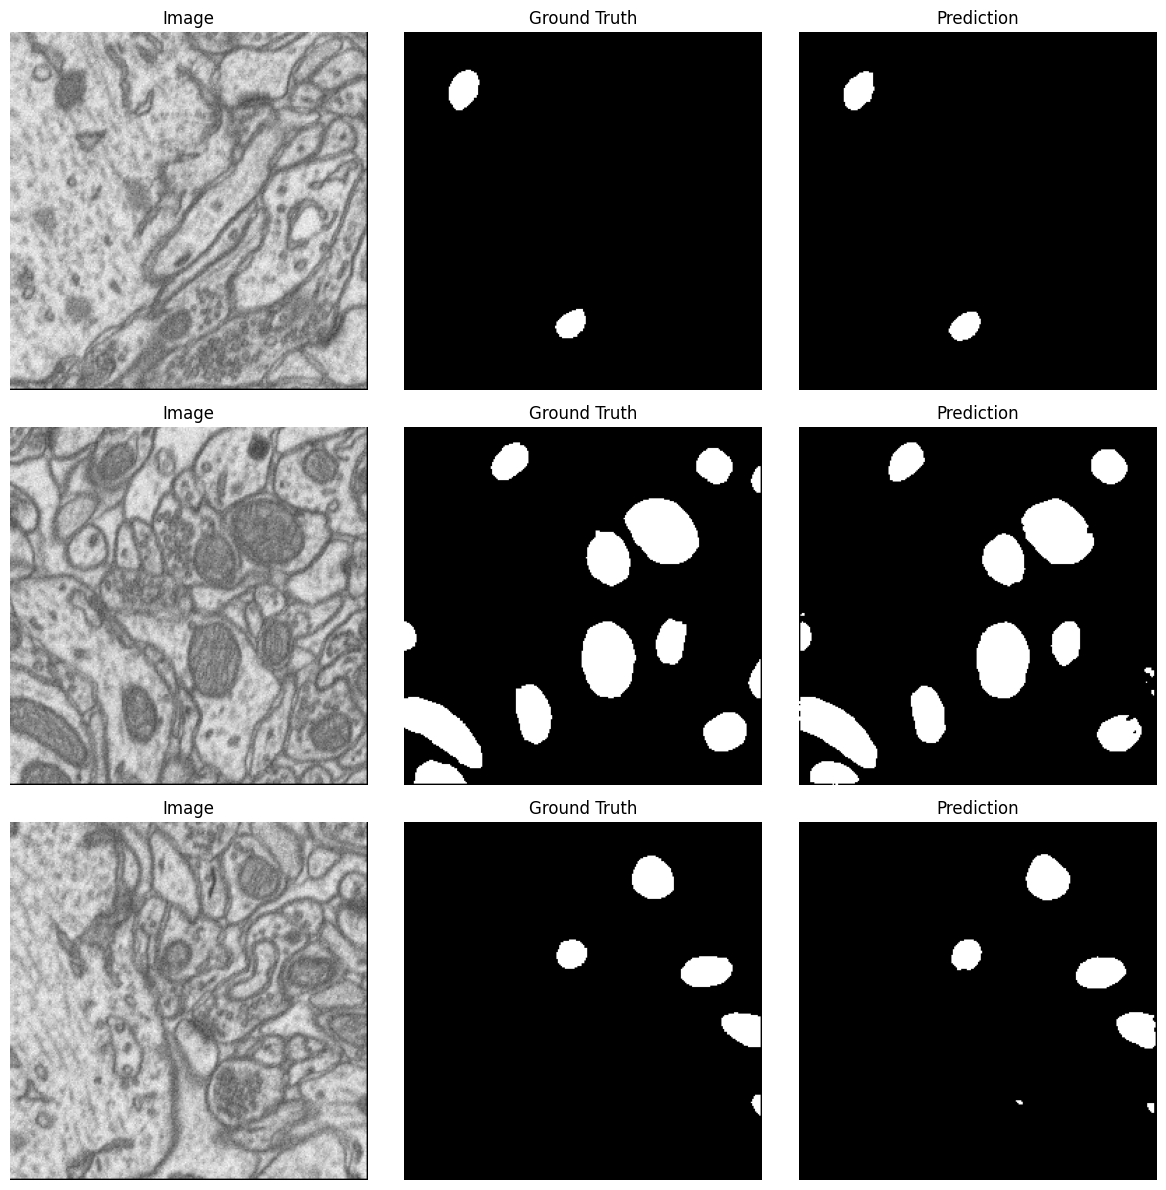

In [31]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [33]:
# TODO: Do you think the classifier works well?
# Yes, the classifier works well. The quantitative metrics are excellent, with a very low test loss of 0.0446 and a high test Dice score of 0.9439, 
# indicating that the model's predictions overlap with the true masks by about 94%. 
# Visually, this high performance is confirmed by the output images: the "Prediction" masks are nearly identical to the "Ground Truth" masks. 

## Bonus: Improve the results. (33 points)

Epoch 1/25 | train_loss=0.0460, train_dice=0.9398 | val_loss=0.0597, val_dice=0.9180
Epoch 2/25 | train_loss=0.0405, train_dice=0.9468 | val_loss=0.0377, val_dice=0.9521
Epoch 3/25 | train_loss=0.0357, train_dice=0.9530 | val_loss=0.0343, val_dice=0.9556
Epoch 4/25 | train_loss=0.0357, train_dice=0.9522 | val_loss=0.0319, val_dice=0.9581
Epoch 5/25 | train_loss=0.0335, train_dice=0.9556 | val_loss=0.0332, val_dice=0.9556
Epoch 6/25 | train_loss=0.0316, train_dice=0.9579 | val_loss=0.0325, val_dice=0.9574
Epoch 7/25 | train_loss=0.0321, train_dice=0.9562 | val_loss=0.0292, val_dice=0.9612
Epoch 8/25 | train_loss=0.0319, train_dice=0.9581 | val_loss=0.0379, val_dice=0.9460
Epoch 9/25 | train_loss=0.0322, train_dice=0.9561 | val_loss=0.0310, val_dice=0.9544
Epoch 10/25 | train_loss=0.0304, train_dice=0.9595 | val_loss=0.0303, val_dice=0.9565
Epoch 11/25 | train_loss=0.0305, train_dice=0.9590 | val_loss=0.0275, val_dice=0.9628
Epoch 12/25 | train_loss=0.0288, train_dice=0.9612 | val_loss=0

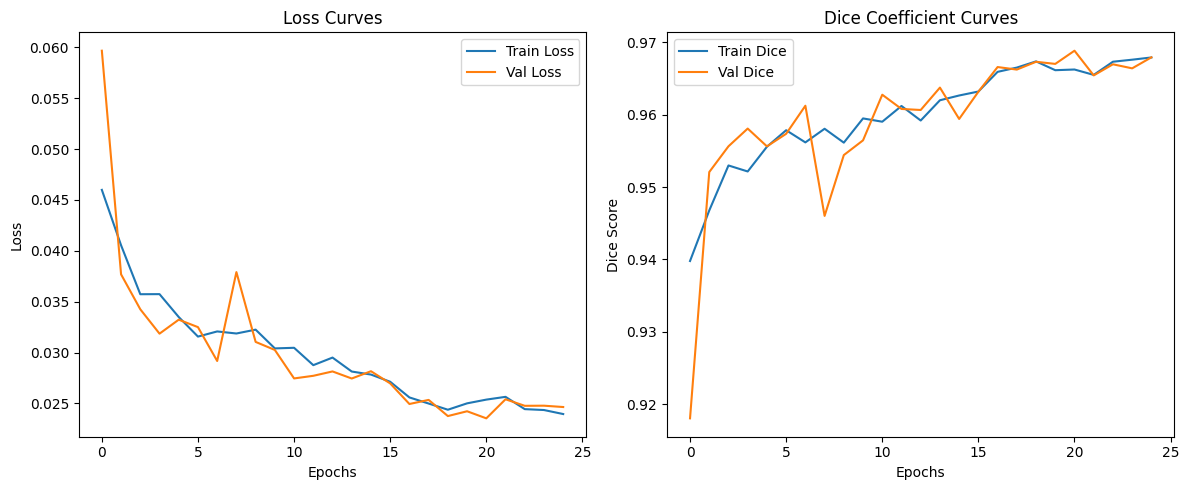

Old Test Dice: 0.9439
New Test Dice: 0.9615


In [37]:
# Try to get better performance and show an improved Dice score on the test set!

# 1. Stronger Data Augmentations
improved_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform() # Great for cells
])

# Reload the training dataset with the new transformations
train_dataset_aug = MitoDataset(X_train, y_train, transform=improved_train_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=16, shuffle=True, num_workers=2)

# 2. Upgraded Model (ResNet34 + ImageNet Weights)
improved_model = smp.Unet(
    encoder_name="resnet34", 
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
).to(device)

improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=1e-3)

num_epochs = 25

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Dice Scores
plt.subplot(1, 2, 2)
plt.plot(train_dices, label='Train Dice')
plt.plot(val_dices, label='Val Dice')
plt.title('Dice Coefficient Curves')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.tight_layout()
plt.show()

improved_model.load_state_dict(torch.load("best_mito_model_v2.pth", map_location=device))
test_loss, test_dice = run_epoch(improved_model, test_loader, optimizer=None)

print(f"Old Test Dice: 0.9439")
print(f"New Test Dice: {test_dice:.4f}")

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#